# anomaly detection — summary

## method
one-class support vector machine trained on queenright data only (all hives, all hours).
the model learns the "normal" feature envelope; queenless observations are scored as novelty.

per-time-slice scoring: one scaler + one detector fitted per hour slice,
so the model does not confuse day/night variation with anomaly.

## evaluation
- anomaly score histograms: visual check that queenless scores shift left (more anomalous)
- mann–whitney u test + area under the receiver operating characteristic curve: 
  non-parametric measure of how separable the two populations are
- cohen's d: effect size in pooled standard deviations

## mosaic visualisation
rows = hourly observations, columns = features (z-scored against queenright baseline).
left strip = anomaly score (darker = more anomalous, red border = bottom 1st percentile).
baseline panel shows the same time window aggregated across queenright hives
(mean, worst, furthest from centroid, or single hive selectable).
columns are reordered by feature similarity for visual clustering.

## findings
- hive 04 queenless period is well separated from baseline
- hive 03 queenless period shows weaker separation if any
- mosaic reveals which features deviate most during queenlessness:
  spectral centroid and mel-frequency cepstral coefficients shift consistently

In [1]:
import dataframes
import anomalies
import paths
import numpy
import pandas

In [2]:
def anomaly_scores_from_dataframe_from_inliers_dataframe(inliers_dataframe):
    scorers = anomalies.scorers_from_inliers_dataframe_and_detector(
        inliers_dataframe,
        
        # IsolationForest(random_state=42),
        # LocalOutlierFactor(novelty=True),
        OneClassSVM(),
        
        # # EllipticEnvelope(random_state=42), # not suitable for hour slices

    )
    return lambda dataframe: anomalies.anomaly_scores_from_dataframe_and_scorers(dataframe, scorers)

In [3]:
all_features = dataframes.from_filepath(paths.all_merged_features_filepath)
all_features =all_features[
    all_features['time_slice'].isin(['14-15', '15-16', '16-17', '17-18'])
]

In [4]:
all_features.head()

,timestamp,hive,time_slice,spectral_centroid_mean,spectral_centroid_std,spectral_bandwidth_mean,spectral_bandwidth_std,spectral_rolloff_mean,spectral_rolloff_std,spectral_flatness_mean,...,middle_to_high_energy_ratio_std,low_modulation_energy,low_peak_modulation_frequency,middle_modulation_energy,middle_peak_modulation_frequency,high_modulation_energy,high_peak_modulation_frequency,queenlessness,temperature,humidity
0,2026-03-07 17:00:00,hive_01,17-18,1704.839665,191.237211,2283.109757,131.021388,4787.536582,572.251570,0.020389,...,0.333739,3.415686e+06,2.031807,3.818026e+06,1.288793,2.246383e+06,1.878730,False,5.0450,54.070
21,2026-03-08 14:00:00,hive_01,14-15,1997.318830,287.113094,2478.732581,165.456756,5461.383803,602.950341,0.029748,...,0.276253,3.563888e+06,1.281117,4.651819e+06,1.003060,2.765173e+06,1.042782,False,11.3475,61.055
22,2026-03-08 15:00:00,hive_01,15-16,1996.112413,254.149965,2465.533402,144.533837,5452.901097,475.880318,0.030558,...,0.374049,2.984711e+06,12.812001,3.802030e+06,1.029449,2.154690e+06,6.730308,False,11.4100,56.775
23,2026-03-08 16:00:00,hive_01,16-17,1955.419577,259.396116,2446.011570,134.520420,5361.855119,491.941928,0.028557,...,0.405604,5.183957e+06,1.419451,3.322930e+06,1.201950,1.717668e+06,2.309177,False,9.1550,57.800
24,2026-03-08 17:00:00,hive_01,17-18,1849.760337,192.084163,2357.209527,111.108924,5077.356577,423.541355,0.027082,...,0.224139,2.578204e+06,1.235839,2.446966e+06,1.936397,1.477377e+06,1.050282,False,7.1600,57.465


In [5]:
queenright_features_dataframe = all_features[all_features['queenlessness'] == False]
queenless_features_dataframe = all_features[all_features['queenlessness'] == True]

In [6]:
queenless_features_dataframe_hive_03 = queenless_features_dataframe[
    queenless_features_dataframe['hive'] == "hive_03"
]
queenless_features_dataframe_hive_04 = queenless_features_dataframe[
    queenless_features_dataframe['hive'] == "hive_04"
]

In [7]:
queenright_features_dataframe_hive_03 = queenright_features_dataframe[
    queenright_features_dataframe['hive'] == "hive_03"
]
queenright_features_dataframe_hive_04 = queenright_features_dataframe[
    queenright_features_dataframe['hive'] == "hive_04"
]

In [8]:
anomaly_scores_from_dataframe = anomalies.anomaly_scores_from_dataframe_from_inliers_dataframe(
    queenright_features_dataframe
)

In [9]:
from matplotlib import pyplot

def histogram_from_array(array, bins=50, title="Histogram"):
    pyplot.figure()
    pyplot.hist(array, bins=bins)
    pyplot.title(title)
    pyplot.show()

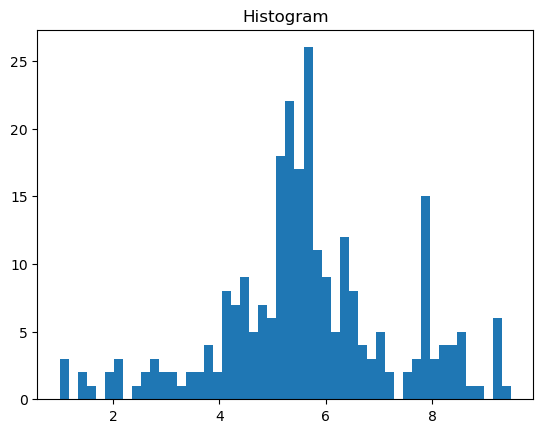

In [10]:
histogram_from_array(anomaly_scores_from_dataframe(queenright_features_dataframe))

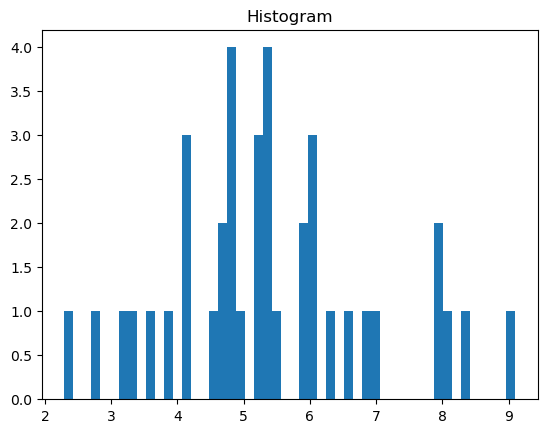

In [11]:
histogram_from_array(anomaly_scores_from_dataframe(queenless_features_dataframe_hive_03))

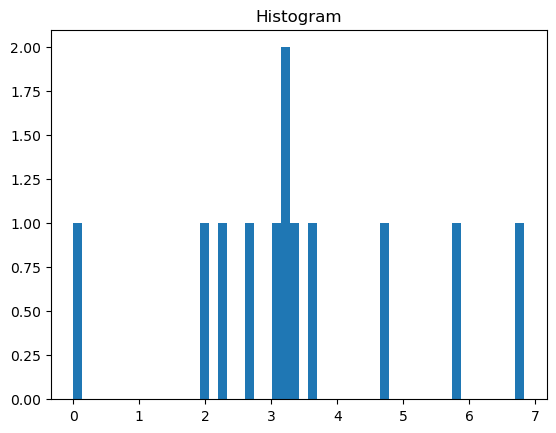

In [12]:
histogram_from_array(anomaly_scores_from_dataframe(queenless_features_dataframe_hive_04))

In [13]:
def investigate_anomaly(
    investigated_features_dataframe,
    baseline_features_dataframe,
    baseline_aggregation,
):
    baseline_zscores = dataframes.zscored_dataframe_from_dataframe_and_baseline(
        baseline_features_dataframe, baseline_features_dataframe,
    )
    investigated_zscores = dataframes.zscored_dataframe_from_dataframe_and_baseline(
        investigated_features_dataframe, baseline_features_dataframe,
    )

    baseline_zscores = dataframes.reordered_columns_from_dataframe(baseline_zscores)
    investigated_zscores = investigated_zscores[baseline_zscores.columns]

    baseline_anomaly_scores = anomaly_scores_from_dataframe(baseline_features_dataframe)
    investigated_anomaly_scores = anomaly_scores_from_dataframe(investigated_features_dataframe)

    anomalies.mosaic_from_zscored_dataframes_and_scores(
        investigated_zscores=investigated_zscores,
        investigated_anomaly_scores=investigated_anomaly_scores,
        investigated_timestamps=investigated_features_dataframe["timestamp"],
        baseline_zscores=baseline_zscores,
        baseline_anomaly_scores=baseline_anomaly_scores,
        baseline_timestamps=baseline_features_dataframe["timestamp"],
        baseline_hives=baseline_features_dataframe["hive"],
        aggregation_method=baseline_aggregation,
    )

In [14]:
queenless_features_dataframe_hive_03

,timestamp,hive,time_slice,spectral_centroid_mean,spectral_centroid_std,spectral_bandwidth_mean,spectral_bandwidth_std,spectral_rolloff_mean,spectral_rolloff_std,spectral_flatness_mean,...,middle_to_high_energy_ratio_std,low_modulation_energy,low_peak_modulation_frequency,middle_modulation_energy,middle_peak_modulation_frequency,high_modulation_energy,high_peak_modulation_frequency,queenlessness,temperature,humidity
593,2026-03-12 14:00:00,hive_03,14-15,1644.204144,239.867267,2219.592730,209.247404,4374.348243,640.036452,0.023878,...,0.419729,5.838178e+06,1.188061,1.103129e+07,1.163061,1.166573e+07,1.468618,True,14.402500,64.595000
594,2026-03-12 15:00:00,hive_03,15-16,1698.130341,245.262334,2255.591188,121.330578,4464.191832,563.678618,0.017980,...,0.706561,3.531548e+06,1.241394,3.643659e+06,1.063894,3.044361e+06,1.261950,True,13.325001,55.580000
595,2026-03-12 16:00:00,hive_03,16-17,1736.772646,217.148105,2237.896853,161.636749,4431.972079,636.856372,0.021643,...,0.496569,1.574019e+07,1.488062,2.044676e+07,1.389728,5.406122e+06,1.627507,True,12.045000,74.400000
596,2026-03-12 17:00:00,hive_03,17-18,1794.329353,343.012739,2219.967727,216.926271,4486.466454,727.615098,0.032528,...,0.431356,5.647979e+06,1.039171,1.097853e+07,1.160561,1.165821e+07,1.076949,True,11.427500,77.767494
617,2026-03-13 14:00:00,hive_03,14-15,1557.380965,210.239505,2158.678006,200.644345,4045.936380,649.539459,0.022178,...,0.357265,5.660408e+06,1.186950,1.213042e+07,1.179727,1.195312e+07,1.081394,True,16.010000,50.745000
618,2026-03-13 15:00:00,hive_03,15-16,1493.575845,202.326052,2087.767457,198.211507,3798.954160,606.287324,0.022237,...,0.369040,5.837574e+06,1.136116,1.162042e+07,2.416955,1.183089e+07,1.557507,True,15.670000,49.910000
619,2026-03-13 16:00:00,hive_03,16-17,1481.483955,274.744872,2047.039192,329.104015,3790.142242,737.547078,0.039929,...,0.457233,6.218271e+06,1.515007,1.172927e+07,1.597507,1.226197e+07,1.250006,True,15.175000,51.180000
620,2026-03-13 17:00:00,hive_03,17-18,1543.313537,174.215648,2126.497505,115.214411,4009.031671,496.296300,0.017816,...,0.358014,2.972723e+06,1.231394,3.589581e+06,1.199450,2.579957e+06,1.039727,True,14.192500,52.140000
641,2026-03-14 14:00:00,hive_03,14-15,1471.555045,190.442493,2130.883090,138.661609,3773.888318,644.045578,0.015466,...,0.306169,3.340905e+06,8.294204,4.677544e+06,1.077227,2.525682e+06,1.009727,True,18.820000,38.955000
642,2026-03-14 15:00:00,hive_03,15-16,1436.696428,207.607509,2089.167578,196.315670,3658.237672,614.122353,0.020563,...,0.326049,4.391959e+06,4.165019,8.124626e+06,1.233894,7.938352e+06,1.462229,True,18.350000,41.155000


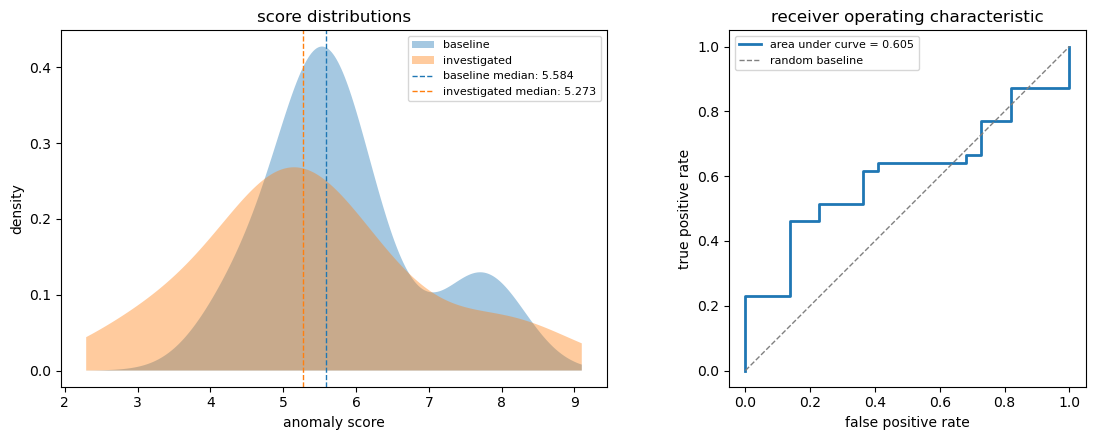

In [26]:
anomalies.discrimination_figure_from_investigated_scores_and_baseline_scores(
    anomaly_scores_from_dataframe(queenless_features_dataframe_hive_03),
    anomaly_scores_from_dataframe(queenright_features_dataframe[queenright_features_dataframe['hive']=='hive_02']),
);

In [16]:
queenless_features_dataframe_hive_04['timestamp']

825   2026-03-09 14:00:00
826   2026-03-09 15:00:00
827   2026-03-09 16:00:00
828   2026-03-09 17:00:00
849   2026-03-10 14:00:00
850   2026-03-10 15:00:00
851   2026-03-10 16:00:00
852   2026-03-10 17:00:00
877   2026-03-11 14:00:00
878   2026-03-11 15:00:00
879   2026-03-11 16:00:00
880   2026-03-11 17:00:00
Name: timestamp, dtype: datetime64[ns]

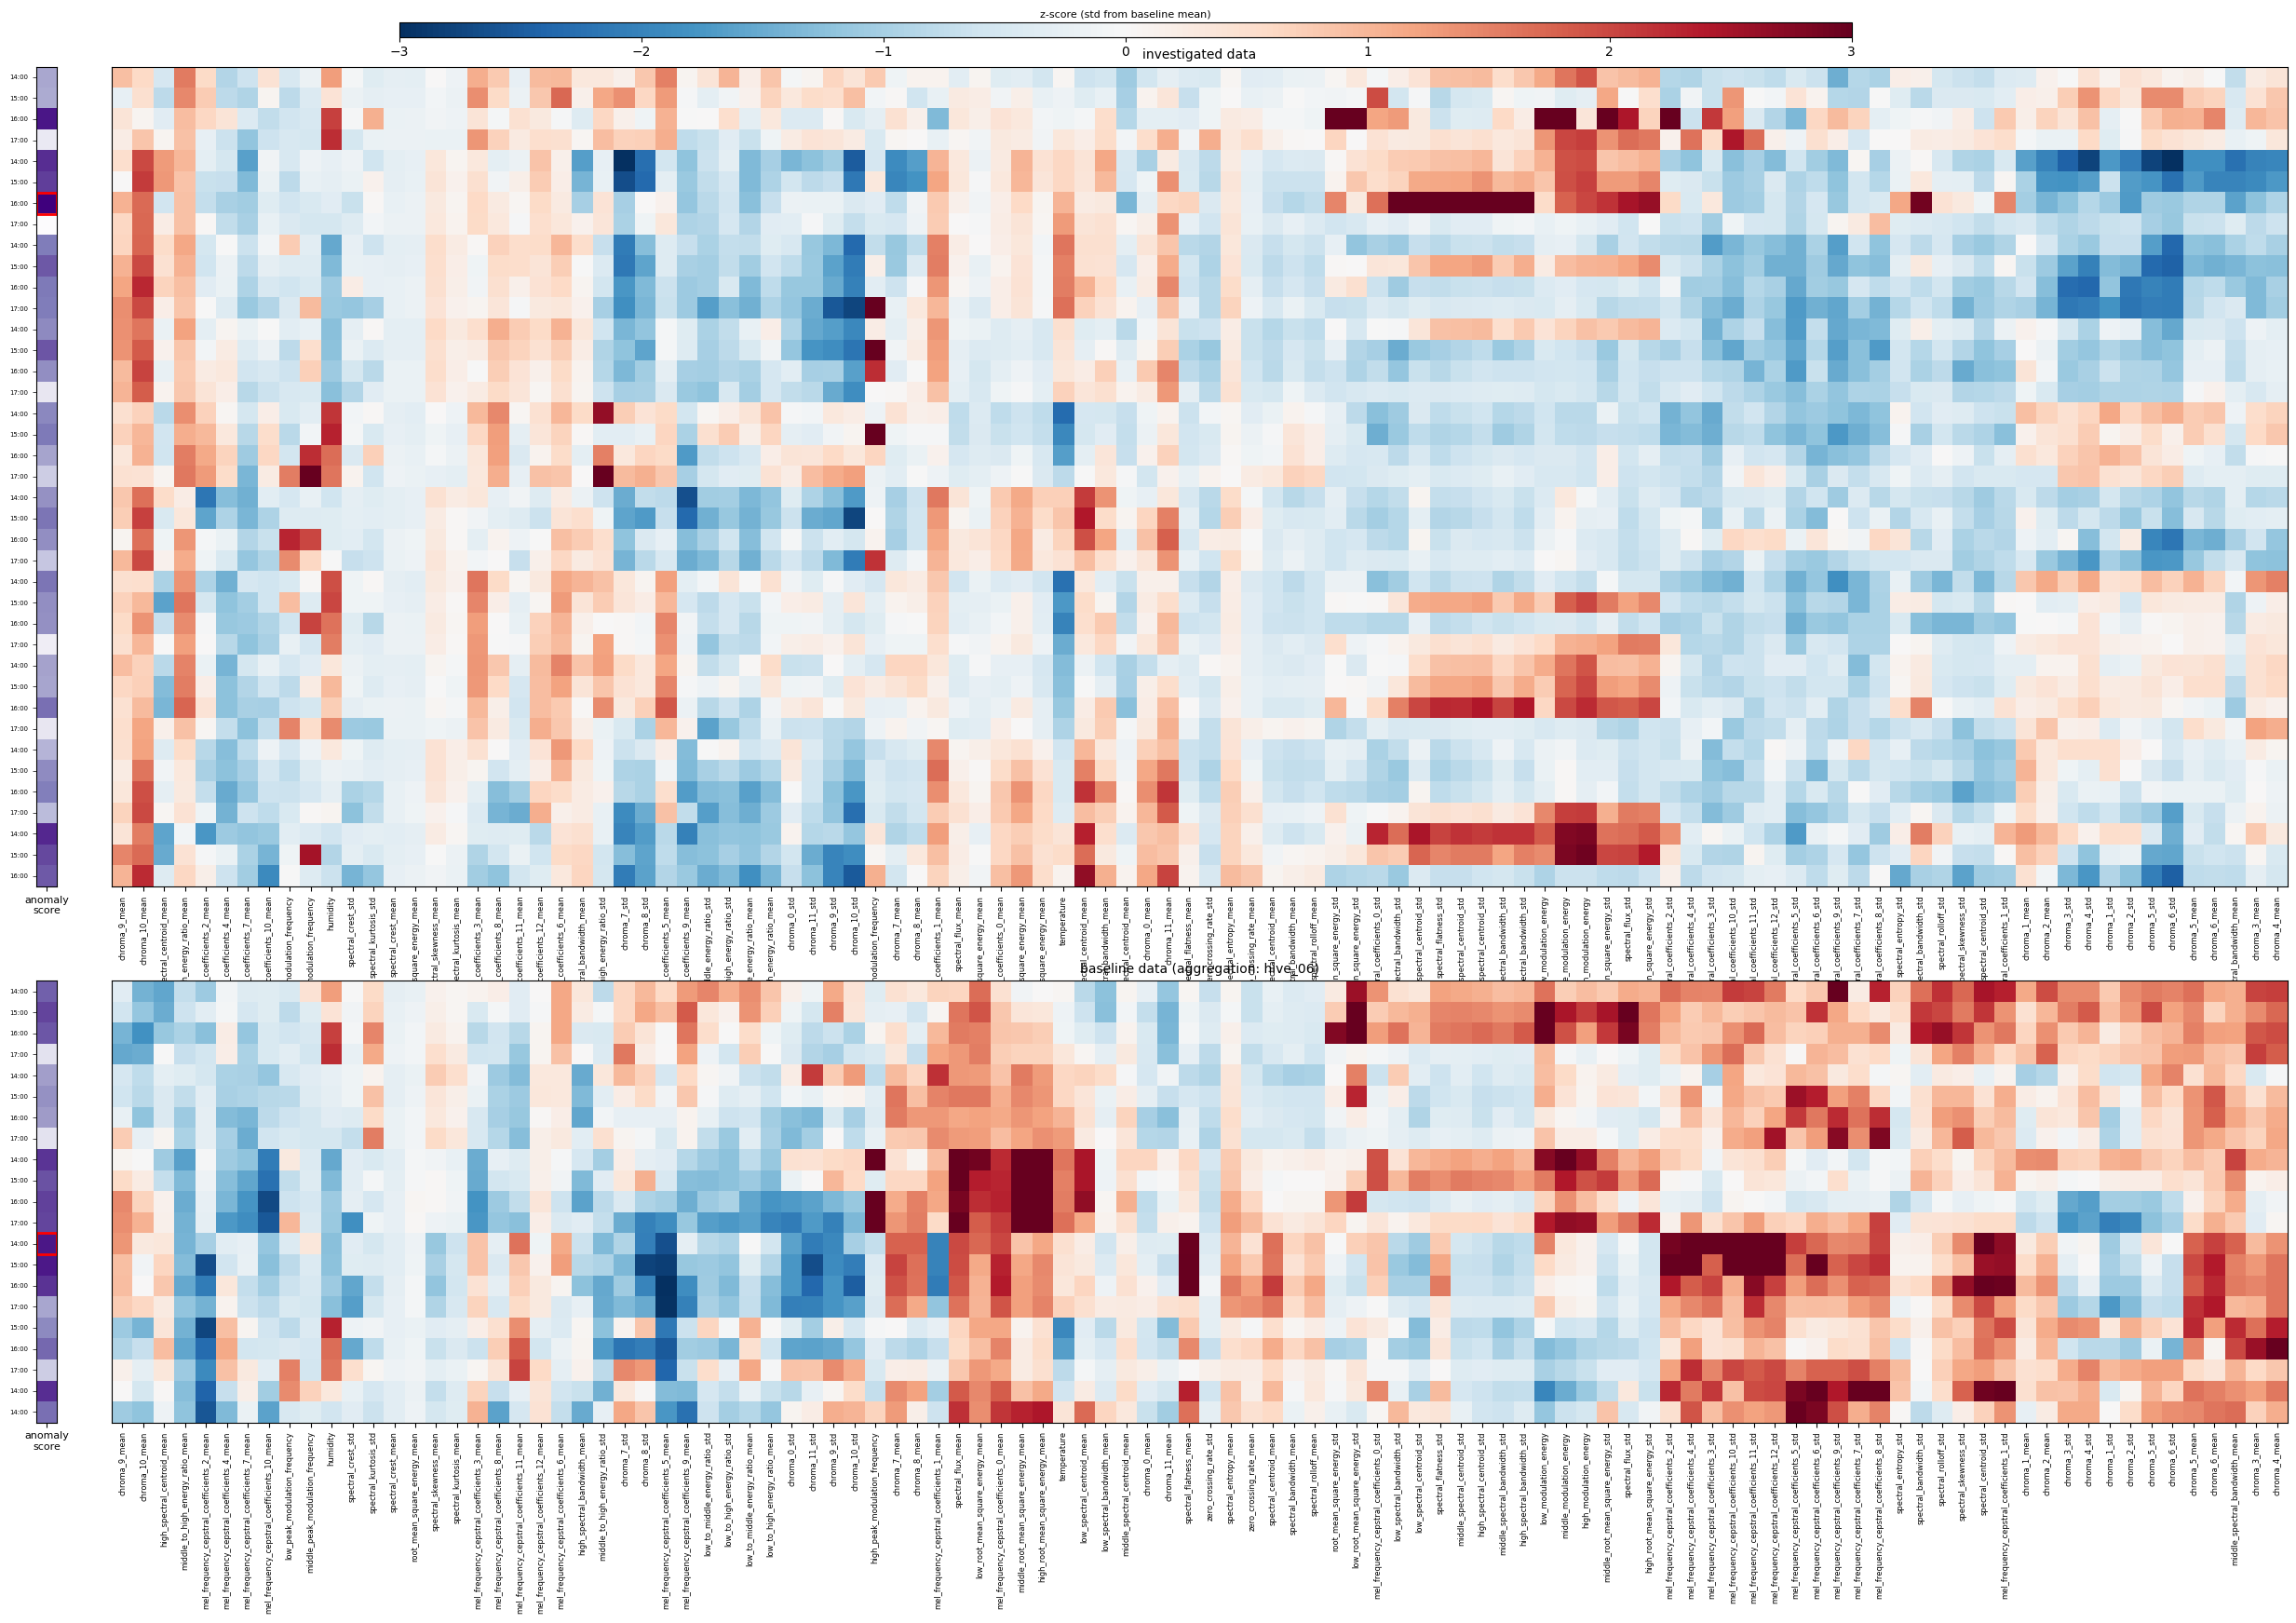

In [24]:
investigate_anomaly(
    queenless_features_dataframe_hive_03,
    queenright_features_dataframe,
    6,
)

{'mann_whitney_u': np.float64(4990.0), 'p_value': np.float64(0.0023588090745002596), 'area_under_curve': np.float64(0.6251220794831343), 'cohens_d': np.float64(0.42723520500595474), 'investigated_median': np.float64(4.858648554041974), 'baseline_median': np.float64(5.583686913688691)}


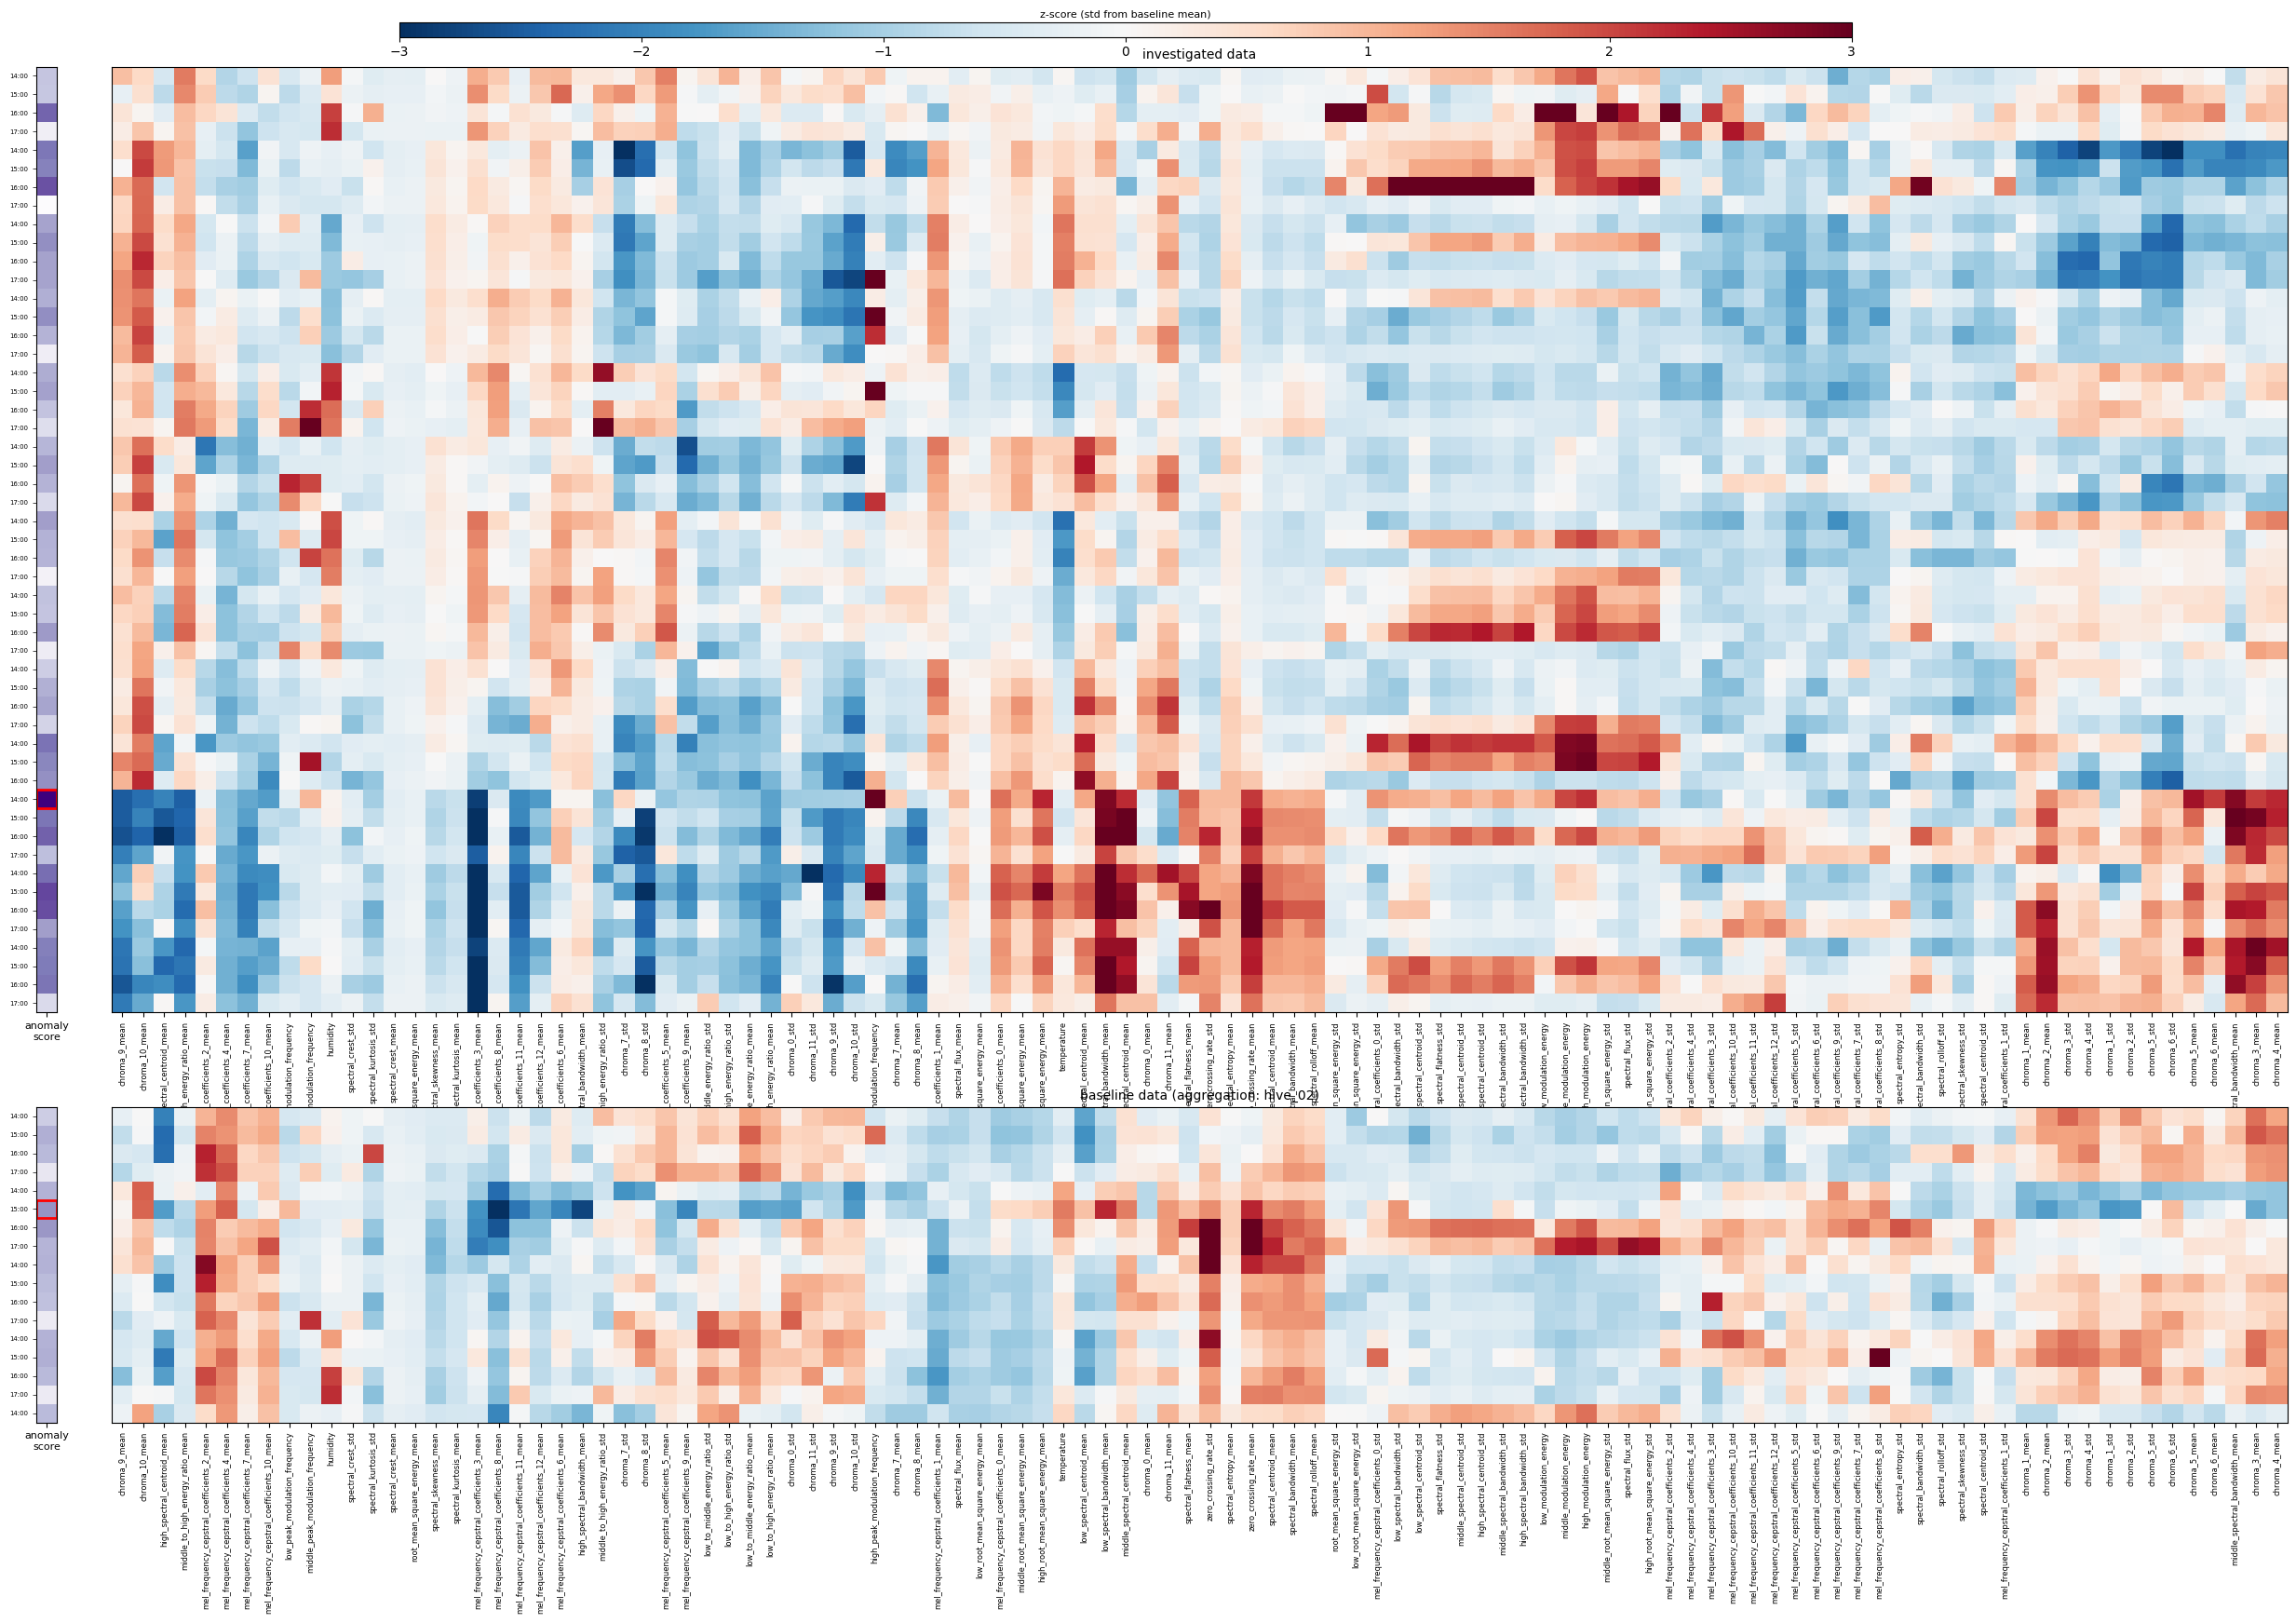

In [20]:
baseline_zscores = dataframes.zscored_dataframe_from_dataframe_and_baseline(
    queenright_features_dataframe, queenright_features_dataframe,
)
investigated_zscores = dataframes.zscored_dataframe_from_dataframe_and_baseline(
    queenless_features_dataframe, queenright_features_dataframe,
)

# reorder columns by feature similarity
baseline_zscores = dataframes.reordered_columns_from_dataframe(baseline_zscores)
investigated_zscores = investigated_zscores[baseline_zscores.columns]

# anomaly scores
queenright_anomaly_scores = anomaly_scores_from_dataframe(queenright_features_dataframe)
queenless_anomaly_scores = anomaly_scores_from_dataframe(queenless_features_dataframe)

# population discrimination
print(anomalies.discrimination_from_scores_and_scores(queenless_anomaly_scores, queenright_anomaly_scores))

# mosaic
anomalies.mosaic_from_zscored_dataframes_and_scores(
    investigated_zscores=investigated_zscores,
    investigated_anomaly_scores=queenless_anomaly_scores,
    investigated_timestamps=queenless_features_dataframe["timestamp"],
    baseline_zscores=baseline_zscores,
    baseline_anomaly_scores=queenright_anomaly_scores,
    baseline_timestamps=queenright_features_dataframe["timestamp"],
    baseline_hives=queenright_features_dataframe["hive"],
    aggregation_method=2,
);